In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import pcntoolkit as ptk
import numpy as np
import pickle

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
unharmonized_features=pd.read_csv(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\results_harmonize\neuroharmonize\unharmonize_rel_a1_O1_age.csv")

In [8]:
unharmonized_features.columns

Index(['subject', 'group', 'SITE', 'age', 'freqs_O1', 'psd_O1', 'TF_O1',
       'IAFp_O1', 'power_delta_O1', 'power_theta_O1', 'power_BGF1_O1',
       'power_BGF2_O1', 'power_BGF3_O1', 'power_beta_O1', 'exponent_O1',
       'offset_O1', 'r2_O1', 'error_O1', 'CF_extalpha_O1',
       'fooof_power_delta_O1', 'fooof_power_theta_O1', 'fooof_power_BGF1_O1',
       'fooof_power_BGF2_O1', 'fooof_power_BGF3_O1', 'fooof_power_beta_O1',
       'pca-one', 'pca-two', 'umap-one', 'umap-two'],
      dtype='object')

## Hierarchical Bayesian Regression

In [3]:
processing_dir = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\HBR"    # replace with a path to your working directory
if not os.path.isdir(processing_dir):
    os.makedirs(processing_dir)
os.chdir(processing_dir)
processing_dir = os.getcwd()

In [6]:
unharmonized_features.SITE.unique()

array(['Dortmund', 'Argentina', 'Chile', 'Cuba', 'Medellin_ld',
       'Medellin_hd', 'CAUEEG', 'Oslo', 'Poland', 'GREECE'], dtype=object)

C:\Users\Luisa\AppData\Local\Temp\ipykernel_12656\1525276071.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oslo['sitenum'] = 0
C:\Users\Luisa\AppData\Local\Temp\ipykernel_12656\1525276071.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_demographics_features['sitenum'] = 0


['Dortmund' 'Argentina' 'Chile' 'Cuba' 'Medellin_ld' 'Medellin_hd'
 'CAUEEG' 'Poland' 'GREECE']
site Dortmund 390
site Argentina 12
site Chile 4
site Cuba 213
site Medellin_ld 40
site Medellin_hd 54
site CAUEEG 463
site Poland 51
site GREECE 23


C:\Users\Luisa\AppData\Local\Temp\ipykernel_12656\1525276071.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  norm_demographics_features['sitenum'].loc[idx] = i
C:\Users\Luisa\AppData\Local\Temp\ipykernel_12656\1525276071.py:12: SettingW

Text(0.5, 0, 'age')

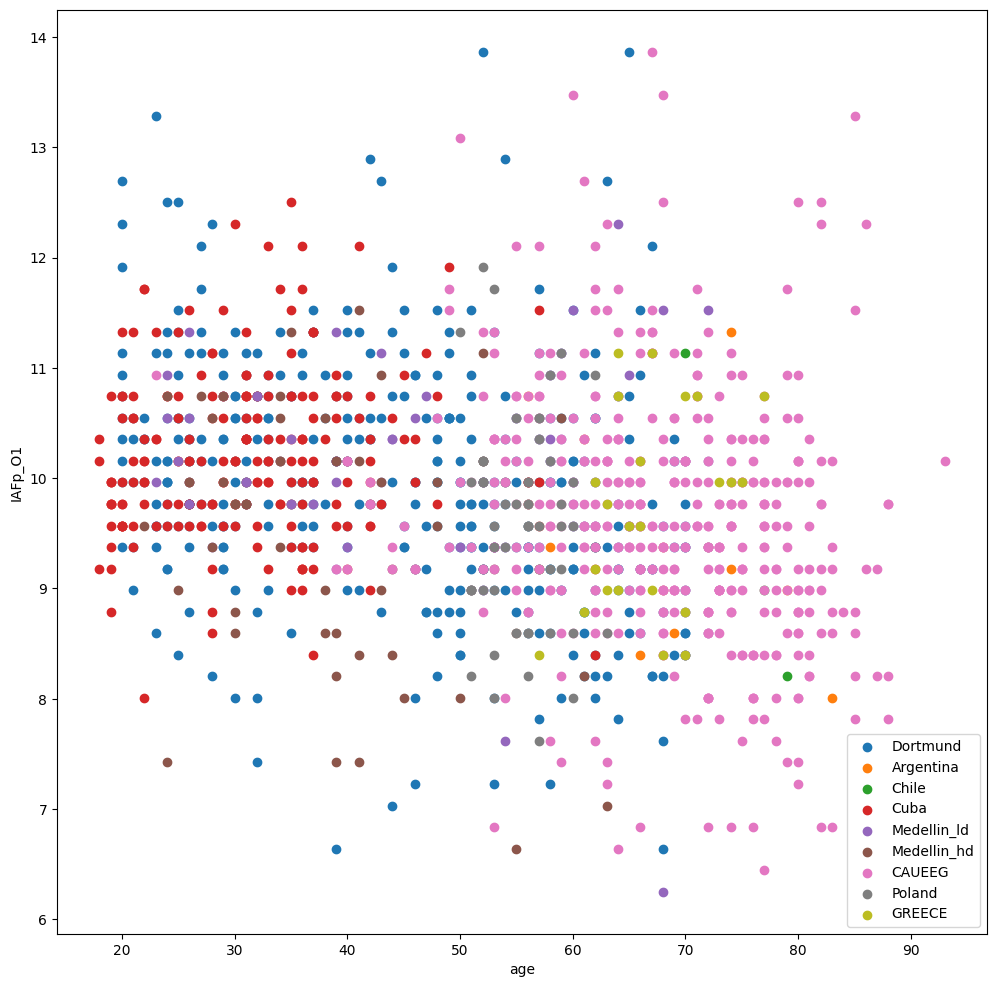

In [4]:
oslo = unharmonized_features.loc[unharmonized_features['SITE'] == 'Oslo']
oslo['sitenum'] = 0
norm_demographics_features = unharmonized_features.loc[unharmonized_features['SITE'] != 'Oslo']
norm_demographics_features['sitenum'] = 0
sites = norm_demographics_features['SITE'].unique()
print(sites)

f, ax = plt.subplots(figsize=(12, 12))

for i,s in enumerate(sites):
    idx = norm_demographics_features['SITE'] == s
    norm_demographics_features['sitenum'].loc[idx] = i

    print('site',s, sum(idx))
    ax.scatter(norm_demographics_features['age'].loc[idx], norm_demographics_features['IAFp_O1'].loc[idx])

ax.legend(sites)
ax.set_ylabel('IAFp_O1')
ax.set_xlabel('age')


In [5]:
tr = np.random.uniform(size=norm_demographics_features.shape[0]) > 0.5
te = ~tr

norm_demographics_features_tr = norm_demographics_features.loc[tr]
norm_demographics_features_te = norm_demographics_features.loc[te]

tr = np.random.uniform(size=oslo.shape[0]) > 0.5
te = ~tr

oslo_tr = oslo.loc[tr]
oslo_te = oslo.loc[te]

print('sample size check')
for i,s in enumerate(sites):
    idx = norm_demographics_features_tr['SITE'] == s
    idxte = norm_demographics_features_te['SITE'] == s
    print(i,s, sum(idx), sum(idxte))

norm_demographics_features_tr.to_csv(processing_dir + '/norm_demographics_features1000_tr.csv')
norm_demographics_features_te.to_csv(processing_dir + '/norm_demographics_features1000_te.csv')
oslo_tr.to_csv(processing_dir + '/norm_demographics_features1000_oslo_tr.csv')
oslo_te.to_csv(processing_dir + '/norm_demographics_features1000_oslo_te.csv')
print(oslo_tr)

sample size check
0 Dortmund 181 209
1 Argentina 7 5
2 Chile 2 2
3 Cuba 110 103
4 Medellin_ld 20 20
5 Medellin_hd 31 23
6 CAUEEG 231 232
7 Poland 31 20
8 GREECE 8 15
      subject group  SITE   age  \
1177  sub-005    HC  Oslo  32.0   
1179  sub-008    HC  Oslo  34.0   
1180  sub-009    HC  Oslo  19.0   
1183  sub-013    HC  Oslo  46.0   
1184  sub-016    HC  Oslo  33.0   
1185  sub-020    HC  Oslo  52.0   
1187  sub-023    HC  Oslo  54.0   
1188  sub-025    HC  Oslo  24.0   
1192  sub-034    HC  Oslo  29.0   
1194  sub-036    HC  Oslo  24.0   
1199  sub-042    HC  Oslo  38.0   
1200  sub-044    HC  Oslo  29.0   
1202  sub-046    HC  Oslo  39.0   
1207  sub-056    HC  Oslo  58.0   
1209  sub-059    HC  Oslo  23.0   
1210  sub-062    HC  Oslo  32.0   
1211  sub-065    HC  Oslo  27.0   
1215  sub-073    HC  Oslo  21.0   
1216  sub-074    HC  Oslo  32.0   
1217  sub-075    HC  Oslo  24.0   
1218  sub-076    HC  Oslo  42.0   
1219  sub-078    HC  Oslo  19.0   
1223  sub-082    HC  Oslo  24

In [39]:
idps =  ['TF_O1',
       'IAFp_O1',]

#### Step 2: Configure HBR inputs: covariates, measures and batch effects

In [35]:
X_train = (norm_demographics_features_tr['age']/100).to_numpy(dtype=float)
Y_train = norm_demographics_features_tr[idps].to_numpy(dtype=float)
batch_effects_train = norm_demographics_features_tr[['sitenum']].to_numpy(dtype=int)

with open('X_train.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_train), file)
with open('Y_train.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_train), file)
with open('trbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_train), file)


X_test = (norm_demographics_features_te['age']/100).to_numpy(dtype=float)
Y_test = norm_demographics_features_te[idps].to_numpy(dtype=float)
batch_effects_test = norm_demographics_features_te[['sitenum']].to_numpy(dtype=int)

with open('X_test.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_test), file)
with open('Y_test.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_test), file)
with open('tsbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_test), file)

# a simple function to quickly load pickle files
def ldpkl(filename: str):
    with open(filename, 'rb') as f:
        return pickle.load(f)

#### Step 3: Files and Folders grooming

In [10]:
respfile = os.path.join(processing_dir, 'Y_train.pkl')       # measurements  (eg cortical thickness) of the training samples (columns: the various features/ROIs, rows: observations or subjects)
covfile = os.path.join(processing_dir, 'X_train.pkl')        # covariates (eg age) the training samples (columns: covariates, rows: observations or subjects)

testrespfile_path = os.path.join(processing_dir, 'Y_test.pkl')       # measurements  for the testing samples
testcovfile_path = os.path.join(processing_dir, 'X_test.pkl')        # covariate file for the testing samples

trbefile = os.path.join(processing_dir, 'trbefile.pkl')      # training batch effects file (eg scanner_id, gender)  (columns: the various batch effects, rows: observations or subjects)
tsbefile = os.path.join(processing_dir, 'tsbefile.pkl')      # testing batch effects file

output_path = os.path.join(processing_dir, 'Models/')    #  output path, where the models will be written
log_dir = os.path.join(processing_dir, 'log/')           #
if not os.path.isdir(output_path):
    os.mkdir(output_path)
if not os.path.isdir(log_dir):
    os.mkdir(log_dir)

outputsuffix = '_estimate'

#### Step 4: Estimating the models

In [17]:
ptk.normative.estimate(covfile=covfile,
                       respfile=respfile,
                       tsbefile=tsbefile,
                       trbefile=trbefile,
                       alg='hbr',
                       log_path=log_dir,
                       binary=True,
                       output_path=output_path, 
                       testcov= testcovfile_path,
                       testresp = testrespfile_path,
                       outputsuffix=outputsuffix, savemodel=True)



inscaler: None
outscaler: None
Processing data in D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\HBR\Y_train.pkl
Estimating model  1 of 2


Initializing NUTS using jitter+adapt_diag_grad...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 17014 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Output()

...

Output()

Normal


Sampling: [y_like]


Output()

Saving model meta-data...
Evaluating the model ...
Writing outputs ...


### Step 5: Transfering the models to unseen sites

In [101]:
idps

['O2_Alpha-1', 'O2_Alpha-2']

In [11]:
X_adapt = (oslo_tr['age']/100).to_numpy(dtype=float)
Y_adapt = oslo_tr[idps].to_numpy(dtype=float)
batch_effects_adapt = oslo_tr[['sitenum']].to_numpy(dtype=int)

with open('X_adaptation.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_adapt), file)
with open('Y_adaptation.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_adapt), file)
with open('adbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_adapt), file)

# Test data (new dataset)
X_test_txfr = (oslo_te['age']/100).to_numpy(dtype=float)
Y_test_txfr = oslo_te[idps].to_numpy(dtype=float)
batch_effects_test_txfr = oslo_te[['sitenum']].to_numpy(dtype=int)

with open('X_test_txfr.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_test_txfr), file)
with open('Y_test_txfr.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_test_txfr), file)
with open('txbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_test_txfr), file)

In [ ]:
ptk.normative.estimate(covfile=covfile,
                       respfile=respfile,
                       tsbefile=tsbefile,
                       trbefile=trbefile,
                       alg='hbr',
                       log_path=log_dir,
                       binary=True,
                       output_path=output_path, testcov= testcovfile_path,
                       testresp = testrespfile_path,
                       outputsuffix=outputsuffix, savemodel=True)

inscaler: None
outscaler: None
Processing data in D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\HBR\Y_train.pkl
Estimating model  1 of 2


Initializing NUTS using jitter+adapt_diag_grad...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 19272 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Output()

...

Output()

Sampling: [y_like]


Output()

Normal


Saving model meta-data...
Evaluating the model ...
Writing outputs ...


In [13]:
X_adapt = (oslo_tr['age']/100).to_numpy(dtype=float)
Y_adapt = oslo_tr[idps].to_numpy(dtype=float)
batch_effects_adapt = oslo_tr[['sitenum']].to_numpy(dtype=int)

with open('X_adaptation.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_adapt), file)
with open('Y_adaptation.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_adapt), file)
with open('adbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_adapt), file)

# Test data (new dataset)
X_test_txfr = (oslo_te['age']/100).to_numpy(dtype=float)
Y_test_txfr = oslo_te[idps].to_numpy(dtype=float)
batch_effects_test_txfr = oslo_te[['sitenum']].to_numpy(dtype=int)

with open('X_test_txfr.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(X_test_txfr), file)
with open('Y_test_txfr.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(Y_test_txfr), file)
with open('txbefile.pkl', 'wb') as file:
    pickle.dump(pd.DataFrame(batch_effects_test_txfr), file)

In [14]:
respfile = os.path.join(processing_dir, 'Y_adaptation.pkl')
covfile = os.path.join(processing_dir, 'X_adaptation.pkl')
testrespfile_path = os.path.join(processing_dir, 'Y_test_txfr.pkl')
testcovfile_path = os.path.join(processing_dir, 'X_test_txfr.pkl')
trbefile = os.path.join(processing_dir, 'adbefile.pkl')
tsbefile = os.path.join(processing_dir, 'txbefile.pkl')

log_dir = os.path.join(processing_dir, 'log_transfer/')
output_path = os.path.join(processing_dir, 'Transfer/')
model_path = os.path.join(processing_dir, 'Models/')  # path to the previously trained models
outputsuffix = '_transfer'  # suffix added to the output files from the transfer function

In [15]:
yhat, s2, z_scores = ptk.normative.transfer(covfile=covfile,
                                            respfile=respfile,
                                            tsbefile=tsbefile,
                                            trbefile=trbefile,
                                            model_path = model_path,
                                            alg='hbr',
                                            log_path=log_dir,
                                            binary=True,
                                            output_path=output_path,
                                            testcov= testcovfile_path,
                                            testresp = testrespfile_path,
                                            outputsuffix=outputsuffix,
                                            savemodel=True)

Loading data ...
Using HBR transform...
Transferring model  1 of 2


Initializing NUTS using jitter+adapt_diag_grad...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_slope_mu, sigma_slope_mu, offset_slope_mu, mu_intercept_mu, sigma_intercept_mu, offset_intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 1 chain for 500 tune and 1_000 draw iterations (500 + 1_000 draws total) took 300 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
Sampling: [y_like]


Output()

...

Output()

Normal


Sampling: [y_like]


Output()

Evaluating the model ...
Writing outputs ...


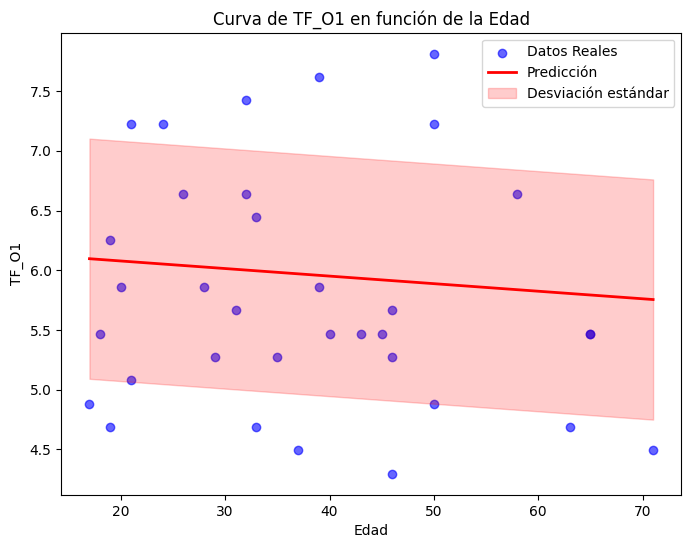

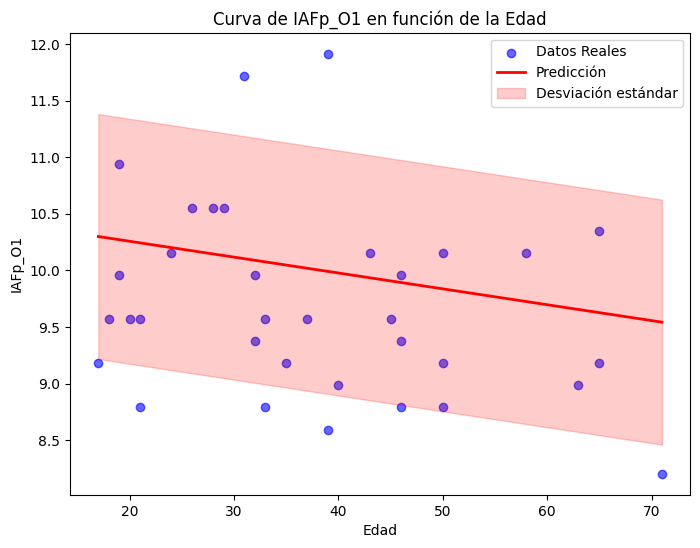

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Cargar datos
demo_te = pd.read_csv("norm_demographics_features1000_oslo_te.csv")
demo_tr = pd.read_csv("norm_demographics_features1000_tr.csv")

# Lista de características a modelar
idps = ['TF_O1', 'IAFp_O1']

# Iterar sobre cada característica
for feature in idps:
    X_train = demo_tr[['age']].values.reshape(-1, 1)
    y_train = demo_tr[feature].values

    X_test = demo_te[['age']].values.reshape(-1, 1)
    y_test = demo_te[feature].values

    # Ajuste del modelo
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predicción y desviación estándar
    y_pred = model.predict(X_test)
    y_std = np.sqrt(np.var(y_train))

    # Obtener la edad y ordenar los datos
    edad = demo_te['age'].values
    sorted_idx = np.argsort(edad)
    edad_sorted = edad[sorted_idx]
    y_pred_sorted = y_pred[sorted_idx]

    # Graficar
    plt.figure(figsize=(8, 6))
    plt.scatter(edad, y_test, label="Datos Reales", color='blue', alpha=0.6)
    plt.plot(edad_sorted, y_pred_sorted, label="Predicción", color='red', linewidth=2)
    plt.fill_between(edad_sorted, y_pred_sorted - y_std, y_pred_sorted + y_std, color='red', alpha=0.2, label="Desviación estándar")
    plt.xlabel("Edad")
    plt.ylabel(feature)
    plt.title(f"Curva de {feature} en función de la Edad")
    plt.legend()
    plt.show()


In [42]:
import pandas as pd

# Cargar datos de entrenamiento y prueba
train_df = pd.read_csv('norm_demographics_features1000_tr.csv')
test_df  = pd.read_csv('norm_demographics_features1000_te.csv')

# Seleccionar la variable de interés (ejemplo: IAFp_O1)
nombre_variable = 'IAFp_O1'
X_train = train_df[['age']]   # covariable: edad de entrenamiento
y_train = train_df[[nombre_variable]]  # variable dependiente de entrenamiento
X_test  = test_df[['age']]    # covariable: edad de prueba
y_test  = test_df[[nombre_variable]]   # variable dependiente de prueba

print("Variables disponibles:", train_df.columns.tolist())  # Ver columnas disponibles (opcional)
print("Usando variable:", nombre_variable)


Variables disponibles: ['Unnamed: 0', 'subject', 'group', 'SITE', 'age', 'freqs_O1', 'psd_O1', 'TF_O1', 'IAFp_O1', 'power_delta_O1', 'power_theta_O1', 'power_BGF1_O1', 'power_BGF2_O1', 'power_BGF3_O1', 'power_beta_O1', 'exponent_O1', 'offset_O1', 'r2_O1', 'error_O1', 'CF_extalpha_O1', 'fooof_power_delta_O1', 'fooof_power_theta_O1', 'fooof_power_BGF1_O1', 'fooof_power_BGF2_O1', 'fooof_power_BGF3_O1', 'fooof_power_beta_O1', 'pca-one', 'pca-two', 'umap-one', 'umap-two', 'sitenum']
Usando variable: IAFp_O1


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pcntoolkit as ptk
import pickle
import os

# 1) Carga de datos de entrenamiento
with open('X_train.pkl','rb') as f:
    X_train = pickle.load(f).values  # Matriz con la edad (escala /100)
with open('Y_train.pkl','rb') as f:
    Y_train = pickle.load(f).values  # Matriz con las IDPs (columnas = ['TF_O1','IAFp_O1', ...])
with open('trbefile.pkl','rb') as f:
    be_train = pickle.load(f).values # Batch effects (sitios) de entrenamiento

# 2) Carga de datos de prueba
with open('X_test.pkl','rb') as f:
    X_test = pickle.load(f).values
with open('Y_test.pkl','rb') as f:
    Y_test = pickle.load(f).values
with open('tsbefile.pkl','rb') as f:
    be_test = pickle.load(f).values

# Unir ambos para graficarlos juntos
X_all = np.concatenate([X_train, X_test])
Y_all = np.concatenate([Y_train, Y_test])
be_all = np.concatenate([be_train, be_test])

print("Shapes -> X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("Shapes -> X_test: ", X_test.shape,  "Y_test: ", Y_test.shape)
print("Shapes -> be_train:", be_train.shape, "be_test:", be_test.shape)


Shapes -> X_train: (621, 1) Y_train: (621, 2)
Shapes -> X_test:  (629, 1) Y_test:  (629, 2)
Shapes -> be_train: (621, 1) be_test: (629, 1)


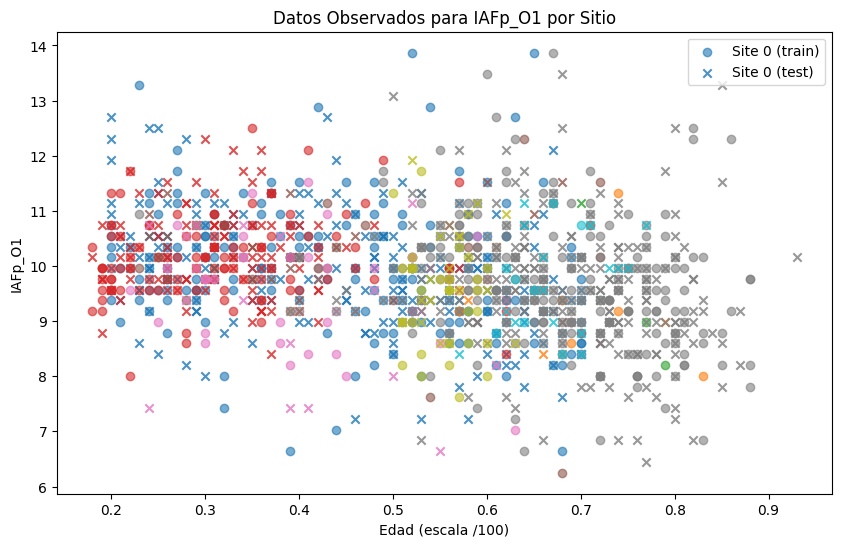

In [46]:
idp_index = 1  # Suponiendo que la segunda columna (1) es 'IAFp_O1'
idp_name = 'IAFp_O1'  # solo para la etiqueta del eje Y

unique_sites = np.unique(be_all)  # sitios existentes

plt.figure(figsize=(10,6))
colors = plt.cm.tab10(np.linspace(0,1,len(unique_sites)))

for i, site_id in enumerate(unique_sites):
    # indices en entrenamiento/prueba para este sitio
    idx_tr = (be_train[:,0] == site_id)
    idx_te = (be_test[:,0] == site_id)
    
    # Graficamos entrenamiento con 'o' y prueba con 'x'
    plt.scatter(X_train[idx_tr], Y_train[idx_tr, idp_index],
                color=colors[i], marker='o', alpha=0.6,
                label=f'Site {site_id} (train)' if i==0 else None)
    plt.scatter(X_test[idx_te],  Y_test[idx_te,  idp_index],
                color=colors[i], marker='x', alpha=0.8,
                label=f'Site {site_id} (test)' if i==0 else None)

plt.xlabel('Edad (escala /100)')
plt.ylabel(idp_name)
plt.title(f'Datos Observados para {idp_name} por Sitio')
plt.legend()
plt.show()



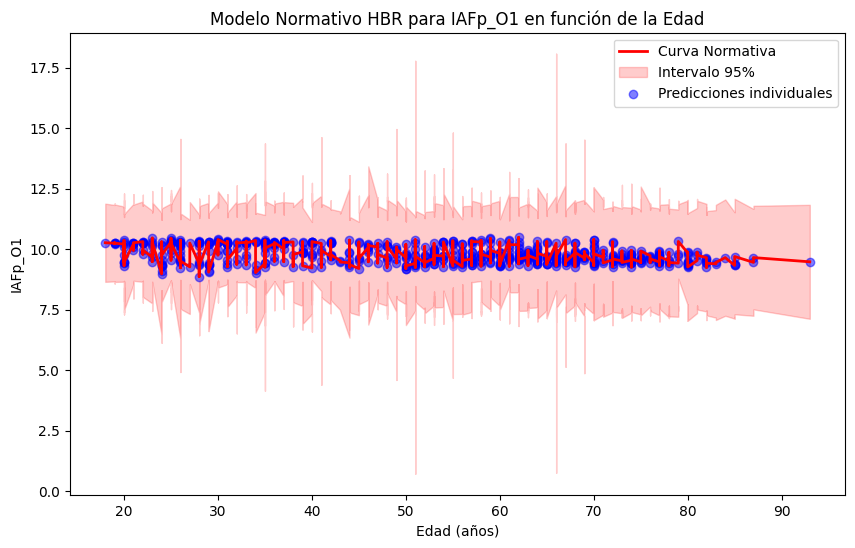

In [58]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rutas de los archivos
model_folder = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\HBR"  # Ajusta según corresponda
yhat_file = f"{model_folder}/yhat_estimate.pkl"
ys2_file = f"{model_folder}/ys2_estimate.pkl"
X_test_file = "X_test.pkl"

# Cargar archivos
with open(yhat_file, "rb") as f:
    yhat = pickle.load(f)
with open(ys2_file, "rb") as f:
    ys2 = pickle.load(f)
with open(X_test_file, "rb") as f:
    X_test = pickle.load(f)

# Convertir a numpy arrays si son DataFrames
if isinstance(yhat, pd.DataFrame):
    yhat = yhat.values
if isinstance(ys2, pd.DataFrame):
    ys2 = ys2.values
if isinstance(X_test, pd.DataFrame):
    X_test = X_test.values

# Suponiendo que usaste:
# idps = ['TF_O1', 'IAFp_O1']
# Y_test tiene dos columnas y queremos graficar 'IAFp_O1' (índice 1).
idp_index = 1
yhat_idp = yhat[:, idp_index]
ys2_idp = ys2[:, idp_index]
std_idp = np.sqrt(ys2_idp)
ci95 = 1.96 * std_idp

# X_test contiene la edad escalada (edad/100). Convertir a edad real:
age_test = X_test.flatten() * 100

# Puede haber una discrepancia en las longitudes; usamos la mínima
n = min(len(age_test), len(yhat_idp))
age_test = age_test[:n]
yhat_idp = yhat_idp[:n]
ci95 = ci95[:n]

# Ordenar según la edad para obtener una curva suave
order = np.argsort(age_test)
age_sorted = age_test[order]
yhat_sorted = yhat_idp[order]
ci95_lower = yhat_sorted - ci95[order]
ci95_upper = yhat_sorted + ci95[order]

# Graficar la curva normativa junto con la banda de incertidumbre
plt.figure(figsize=(10,6))
plt.plot(age_sorted, yhat_sorted, color="red", linewidth=2, label="Curva Normativa")
plt.fill_between(age_sorted, ci95_lower, ci95_upper, color="red", alpha=0.2, label="Intervalo 95%")
plt.scatter(age_test, yhat_idp, color="blue", alpha=0.5, label="Predicciones individuales")
plt.xlabel("Edad (años)")
plt.ylabel("IAFp_O1")
plt.title("Modelo Normativo HBR para IAFp_O1 en función de la Edad")
plt.legend()
plt.show()


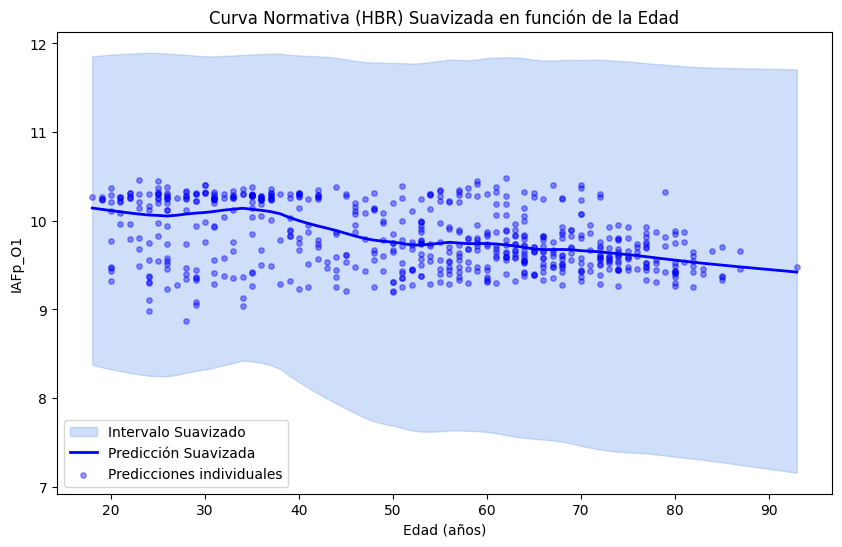

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Si no tienes statsmodels instalado: pip install statsmodels
import statsmodels.api as sm
lowess = sm.nonparametric.lowess

# -------------------------------------------------------------------------
# 1) CARGA DE DATOS (YA CALCULADOS)
# -------------------------------------------------------------------------
# Supongamos que ya cargaste:
#   age_test     -> array con la edad real de cada sujeto (en años).
#   yhat_idp     -> array con la predicción para la IDP (ej: IAFp_O1).
#   ci95         -> array con el intervalo 95% para cada sujeto (ej: ±1.96·std).

# Ejemplo hipotético:
# age_test = np.array([...])      # forma (N,)
# yhat_idp = np.array([...])      # forma (N,)
# ci95 = np.array([...])          # forma (N,)

# Calcula límites inferior y superior
ci95_lower = yhat_idp - ci95
ci95_upper = yhat_idp + ci95

# -------------------------------------------------------------------------
# 2) ORDENAR POR EDAD
# -------------------------------------------------------------------------
data = np.column_stack((age_test, yhat_idp, ci95_lower, ci95_upper))
# Ordenamos por la columna 0 (edad)
data_sorted = data[data[:, 0].argsort()]

ages_sorted  = data_sorted[:, 0]
mean_sorted  = data_sorted[:, 1]
lower_sorted = data_sorted[:, 2]
upper_sorted = data_sorted[:, 3]

# -------------------------------------------------------------------------
# 3) SUAVIZADO LOCAL (LOWESS)
# -------------------------------------------------------------------------
# Ajusta 'frac' (entre ~0.1 y 0.5) según cuán suave quieras la curva
frac_val = 0.2

mean_smooth  = lowess(mean_sorted,  ages_sorted, frac=frac_val, return_sorted=True)
lower_smooth = lowess(lower_sorted, ages_sorted, frac=frac_val, return_sorted=True)
upper_smooth = lowess(upper_sorted, ages_sorted, frac=frac_val, return_sorted=True)

# mean_smooth, lower_smooth y upper_smooth tienen forma (N,2):
# [:,0] = edad ordenada, [:,1] = valor suavizado

# -------------------------------------------------------------------------
# 4) GRÁFICA: CURVA SUAVIZADA + BANDA DE INCERTIDUMBRE
# -------------------------------------------------------------------------
plt.figure(figsize=(10,6))

# Banda de incertidumbre (área entre lower_smooth y upper_smooth)
plt.fill_between(
    mean_smooth[:,0],
    lower_smooth[:,1],
    upper_smooth[:,1],
    color='cornflowerblue',
    alpha=0.3,
    label='Intervalo Suavizado'
)

# Curva suavizada (predicción promedio)
plt.plot(mean_smooth[:,0], mean_smooth[:,1],
         color='blue', linewidth=2, label='Predicción Suavizada')

# Puntos originales (opcional, para ver la dispersión)
plt.scatter(ages_sorted, mean_sorted, color='blue', alpha=0.4, s=15,
            label='Predicciones individuales')

plt.xlabel("Edad (años)")
plt.ylabel("IAFp_O1")
plt.title("Curva Normativa (HBR) Suavizada en función de la Edad")
plt.legend()
plt.show()


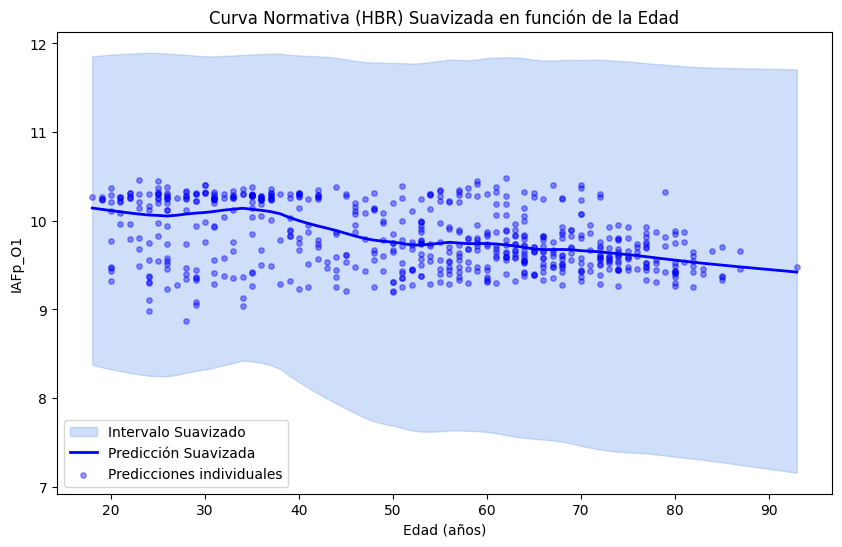

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Si no tienes statsmodels instalado: pip install statsmodels
import statsmodels.api as sm
lowess = sm.nonparametric.lowess

# -------------------------------------------------------------------------
# 1) CARGA DE DATOS (YA CALCULADOS)
# -------------------------------------------------------------------------
# Supongamos que ya cargaste:
#   age_test     -> array con la edad real de cada sujeto (en años).
#   yhat_idp     -> array con la predicción para la IDP (ej: IAFp_O1).
#   ci95         -> array con el intervalo 95% para cada sujeto (ej: ±1.96·std).

# Ejemplo hipotético:
# age_test = np.array([...])      # forma (N,)
# yhat_idp = np.array([...])      # forma (N,)
# ci95 = np.array([...])          # forma (N,)

# Calcula límites inferior y superior
ci95_lower = yhat_idp - ci95
ci95_upper = yhat_idp + ci95

# -------------------------------------------------------------------------
# 2) ORDENAR POR EDAD
# -------------------------------------------------------------------------
data = np.column_stack((age_test, yhat_idp, ci95_lower, ci95_upper))
# Ordenamos por la columna 0 (edad)
data_sorted = data[data[:, 0].argsort()]

ages_sorted  = data_sorted[:, 0]
mean_sorted  = data_sorted[:, 1]
lower_sorted = data_sorted[:, 2]
upper_sorted = data_sorted[:, 3]

# -------------------------------------------------------------------------
# 3) SUAVIZADO LOCAL (LOWESS)
# -------------------------------------------------------------------------
# Ajusta 'frac' (entre ~0.1 y 0.5) según cuán suave quieras la curva
frac_val = 0.2

mean_smooth  = lowess(mean_sorted,  ages_sorted, frac=frac_val, return_sorted=True)
lower_smooth = lowess(lower_sorted, ages_sorted, frac=frac_val, return_sorted=True)
upper_smooth = lowess(upper_sorted, ages_sorted, frac=frac_val, return_sorted=True)

# mean_smooth, lower_smooth y upper_smooth tienen forma (N,2):
# [:,0] = edad ordenada, [:,1] = valor suavizado

# -------------------------------------------------------------------------
# 4) GRÁFICA: CURVA SUAVIZADA + BANDA DE INCERTIDUMBRE
# -------------------------------------------------------------------------
plt.figure(figsize=(10,6))

# Banda de incertidumbre (área entre lower_smooth y upper_smooth)
plt.fill_between(
    mean_smooth[:,0],
    lower_smooth[:,1],
    upper_smooth[:,1],
    color='cornflowerblue',
    alpha=0.3,
    label='Intervalo Suavizado'
)

# Curva suavizada (predicción promedio)
plt.plot(mean_smooth[:,0], mean_smooth[:,1],
         color='blue', linewidth=2, label='Predicción Suavizada')

# Puntos originales (opcional, para ver la dispersión)
plt.scatter(ages_sorted, mean_sorted, color='blue', alpha=0.4, s=15,
            label='Predicciones individuales')

plt.xlabel("Edad (años)")
plt.ylabel("IAFp_O1")
plt.title("Curva Normativa (HBR) Suavizada en función de la Edad")
plt.legend()
plt.show()


In [ ]:



# =============================================================================
# 3. ASIGNAR CÓDIGO DE SITIO (sitenum)
# =============================================================================
unique_sites = df['SITE'].unique()
site_map = {s: i for i, s in enumerate(unique_sites)}
df['sitenum'] = df['SITE'].map(site_map)

# =============================================================================
# 4. SEPARAR GRUPOS: CONTROLES (HC) Y MCI
# =============================================================================
df_HC = df[df['group'] == 'HC'].copy()
df_MCI = df[df['group'] == 'MCI'].copy()

# =============================================================================
# 5. DIVIDIR LOS CONTROLES EN TRAIN/TEST
# =============================================================================
# Por ejemplo, 70% para entrenar y 30% para test interno
mask = np.random.rand(len(df_HC)) < 0.7
df_HC_train = df_HC[mask].copy()
df_HC_test = df_HC[~mask].copy()

# Guardar CSVs para referencia (opcional)
df_HC_train.to_csv(os.path.join(processing_dir, "HC_train.csv"), index=False)
df_HC_test.to_csv(os.path.join(processing_dir, "HC_test.csv"), index=False)
df_MCI.to_csv(os.path.join(processing_dir, "MCI.csv"), index=False)

# =============================================================================
# 6. GENERAR MATRICES X, Y Y BATCH EFFECTS
# =============================================================================
def generar_datos(df_, idps_list):
    # Covariable: edad escalada (edad/100)
    X = (df_['age'] / 100).to_numpy(dtype=float).reshape(-1,1)
    # Respuestas: todas las IDPs
    Y = df_[idps_list].to_numpy(dtype=float)
    # Batch effects: sitenum
    BE = df_[['sitenum']].to_numpy(dtype=int)
    return X, Y, BE

X_train, Y_train, BE_train = generar_datos(df_HC_train, idps)
X_test, Y_test, BE_test    = generar_datos(df_HC_test, idps)

# Guardar en formato pickle para PCNtoolkit
with open("X_train.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(X_train), f)
with open("Y_train.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(Y_train, columns=idps), f)
with open("trbefile.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(BE_train), f)

with open("X_test.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(X_test), f)
with open("Y_test.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(Y_test, columns=idps), f)
with open("tsbefile.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(BE_test), f)

# =============================================================================
# 7. ENTRENAR EL MODELO NORMATIVO CON HBR (usando solo HC)
# =============================================================================
covfile = os.path.join(processing_dir, "X_train.pkl")
respfile = os.path.join(processing_dir, "Y_train.pkl")
trbefile = os.path.join(processing_dir, "trbefile.pkl")
testcovfile = os.path.join(processing_dir, "X_test.pkl")
testrespfile = os.path.join(processing_dir, "Y_test.pkl")
tsbefile = os.path.join(processing_dir, "tsbefile.pkl")

output_path = os.path.join(processing_dir, "Models")
log_dir     = os.path.join(processing_dir, "log")
os.makedirs(output_path, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
outputsuffix = "_estimate"

ptk.normative.estimate(
    covfile=covfile,
    respfile=respfile,
    tsbefile=tsbefile,
    trbefile=trbefile,
    alg="hbr",
    log_path=log_dir,
    binary=True,
    output_path=output_path,
    testcov=testcovfile,
    testresp=testrespfile,
    outputsuffix=outputsuffix,
    savemodel=True
)

print("Modelo normativo HBR entrenado y guardado en:", output_path)

# =============================================================================
# 8. TRANSFERENCIA: APLICAR EL MODELO A SUJETOS MCI
# =============================================================================
# Generar datos para MCI
def generar_datos_MCI(df_, idps_list):
    X = (df_['age'] / 100).to_numpy(dtype=float).reshape(-1,1)
    Y = df_[idps_list].to_numpy(dtype=float)
    BE = df_[['sitenum']].to_numpy(dtype=int)
    return X, Y, BE

X_MCI, Y_MCI, BE_MCI = generar_datos_MCI(df_MCI, idps)
with open("X_MCI.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(X_MCI), f)
with open("Y_MCI.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(Y_MCI, columns=idps), f)
with open("mci_befile.pkl", "wb") as f:
    pickle.dump(pd.DataFrame(BE_MCI), f)

transfer_output_path = os.path.join(processing_dir, "Transfer")
transfer_log_dir = os.path.join(processing_dir, "log_transfer")
os.makedirs(transfer_output_path, exist_ok=True)
os.makedirs(transfer_log_dir, exist_ok=True)
outputsuffix_transfer = "_transfer"

yhat_MCI, s2_MCI, z_scores_MCI = ptk.normative.transfer(
    covfile=os.path.join(processing_dir, "X_MCI.pkl"),
    respfile=os.path.join(processing_dir, "Y_MCI.pkl"),
    tsbefile=tsbefile,
    trbefile=trbefile,  # Usamos el mismo modelo entrenado
    model_path=output_path,
    alg="hbr",
    log_path=transfer_log_dir,
    binary=True,
    output_path=transfer_output_path,
    testcov=os.path.join(processing_dir, "X_MCI.pkl"),
    testresp=os.path.join(processing_dir, "Y_MCI.pkl"),
    outputsuffix=outputsuffix_transfer,
    savemodel=True
)

print("Transferencia realizada para MCI, resultados guardados en:", transfer_output_path)

# =============================================================================
# 9. GENERAR INFORME CON GRÁFICOS POR IDP
# =============================================================================
# Queremos graficar la curva normativa (obtenida de la estimación en HC) y superponer
# los puntos reales de HC y MCI en diferentes colores para ver las desviaciones.
#
# En este ejemplo usaremos los resultados de la estimación del modelo (guardados en Models)
# y los datos completos de HC y MCI (sin partición) para graficar la trayectoria normativa.

# Cargar datos completos de HC y MCI
df_HC_full = df_HC.copy()  # todos los controles
df_MCI_full = df_MCI.copy()  # todos los MCI

# Para graficar la curva normativa, vamos a utilizar los datos de test de HC.
# Cargamos X_test y las predicciones del modelo
with open(os.path.join(output_path, "yhat_estimate.pkl"), "rb") as f:
    yhat_est = pickle.load(f)
with open(os.path.join(output_path, "ys2_estimate.pkl"), "rb") as f:
    ys2_est = pickle.load(f)

# Convertir a numpy arrays si son DataFrame
if isinstance(yhat_est, pd.DataFrame):
    yhat_est = yhat_est.values
if isinstance(ys2_est, pd.DataFrame):
    ys2_est = ys2_est.values
with open("X_test.pkl", "rb") as f:
    X_test_loaded = pickle.load(f)
if isinstance(X_test_loaded, pd.DataFrame):
    X_test_loaded = X_test_loaded.values

# La covariable es la edad escalada (edad/100); convertimos a edad real
age_HC = X_test_loaded.flatten() * 100

# Calculamos la banda de confianza a partir de la varianza
std_est = np.sqrt(ys2_est)
ci95_est = 1.96 * std_est

# Usaremos LOWESS para suavizar la curva normativa
lowess = sm.nonparametric.lowess
frac_val = 0.3  # Ajusta este parámetro según lo suave que desees

# Creamos un PDF para guardar un gráfico por IDP
pdf_path = os.path.join(processing_dir, "informe_normativo.pdf")
with PdfPages(pdf_path) as pdf:
    for i, idp in enumerate(idps):
        plt.figure(figsize=(10,6))
        # Extraemos la predicción y banda para la IDP i
        yhat_idp = yhat_est[:, i]
        ci95_idp = ci95_est[:, i]
        # Ordenamos por edad
        order = np.argsort(age_HC)
        ages_sorted = age_HC[order]
        yhat_sorted = yhat_idp[order]
        ci95_sorted = ci95_idp[order]
        # Suavizamos la curva normativa usando LOWESS
        smooth = lowess(yhat_sorted, ages_sorted, frac=frac_val, return_sorted=True)
        
        # Graficar la curva normativa suavizada
        plt.plot(smooth[:,0], smooth[:,1], color="black", linewidth=2, label="Curva Normativa (HC)")
        # Graficar la banda de confianza (sin suavizado)
        plt.fill_between(ages_sorted, yhat_sorted - ci95_sorted, yhat_sorted + ci95_sorted,
                         color="gray", alpha=0.3, label="Intervalo 95%")
        
        # Graficar puntos reales:
        # HC en azul
        plt.scatter(df_HC_full["age"], df_HC_full[idp], color="blue", alpha=0.5, label="HC", s=20)
        # MCI en rojo
        plt.scatter(df_MCI_full["age"], df_MCI_full[idp], color="red", alpha=0.5, label="MCI", s=20)
        
        plt.xlabel("Edad (años)")
        plt.ylabel(idp)
        plt.title(f"Normative Model para {idp} vs. Edad")
        plt.legend()
        plt.grid(True)
        pdf.savefig()
        plt.close()

print("Informe generado en:", pdf_path)


Index(['subject', 'group', 'SITE', 'avg_TF_ROI_PO', 'avg_IAFp_ROI_PO',
       'avg_power_ab_delta_ROI_PO', 'avg_power_ab_theta_ROI_PO',
       'avg_power_ab_BGF1_ROI_PO', 'avg_power_ab_BGF2_ROI_PO',
       'avg_power_ab_BGF3_ROI_PO', 'avg_power_ab_beta_ROI_PO',
       'avg_power_delta_ROI_PO', 'avg_power_theta_ROI_PO',
       'avg_power_BGF1_ROI_PO', 'avg_power_BGF2_ROI_PO',
       'avg_power_BGF3_ROI_PO', 'avg_power_beta_ROI_PO', 'avg_exponent_ROI_PO',
       'avg_offset_ROI_PO', 'avg_cf_extalpha_ROI_PO',
       'avg_fooof_power_ab_delta_ROI_PO', 'avg_fooof_power_ab_theta_ROI_PO',
       'avg_fooof_power_ab_BGF1_ROI_PO', 'avg_fooof_power_ab_BGF2_ROI_PO',
       'avg_fooof_power_ab_BGF3_ROI_PO', 'avg_fooof_power_ab_beta_ROI_PO',
       'avg_fooof_power_delta_ROI_PO', 'avg_fooof_power_theta_ROI_PO',
       'avg_fooof_power_BGF1_ROI_PO', 'avg_fooof_power_BGF2_ROI_PO',
       'avg_fooof_power_BGF3_ROI_PO', 'avg_fooof_power_beta_ROI_PO', 'age'],
      dtype='object')
